# Análise das Transcrições — Estimativa de `seq_len`

**Objetivo:** explorar as transcrições para entender a distribuição temporal dos blocos de fala e silêncio, de modo a determinar o comprimento de sequência (`seq_len`) que será usado nas entradas do LSTM.

**Estratégia de rotulagem por segmento:**
- `label = 1` (fala/vocal): texto real + marcadores vocais como `[laughs]`, `[cough]` etc.
- `label = 0` (ruído/silêncio): apenas `[noise]` ou `[inaudible ...]`

**Tratamento de sobreposição de speakers:** OR logic — se qualquer speaker está falando num dado frame, `label = 1`.

> **Observação:** neste notebook não há dependência de arquivos de áudio `.wav`. Toda a análise é feita a partir das transcrições.

In [1]:
import json
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (13, 4)

# Caminho raiz das transcrições (relativo ao notebook)
TRANSCRIPTIONS_DIR = Path("transcriptions")
SPLITS = ["dev"]

# Resolução temporal do grid de frames — deve ser igual ao hop_size
# que será usado na extração de features do módulo preprocess.py
HOP_SIZE = 0.008  # 8ms por frame

os.makedirs("plots", exist_ok=True)

## 1. Carregando e Parseando as Transcrições

In [2]:
def parse_time(time_str: str) -> float:
    """Converte 'HH:MM:SS.ss' para segundos."""
    h, m, s = time_str.split(":")
    return int(h) * 3600 + int(m) * 60 + float(s)


def segment_label(words: str) -> int:
    """
    Classifica um segmento de transcrição como fala (1) ou ruído (0).

    Regras:
    - Se houver texto real (fora de colchetes) → 1
    - Se o conteúdo for só marcadores, verifica o tipo:
        - [noise] ou [inaudible ...] → 0
        - Qualquer outro marcador ([laughs], [cough], etc.) → 1
    """
    text_clean = re.sub(r"\[[^\]]*\]", "", words).strip()
    if text_clean:
        return 1  # há texto real

    markers = re.findall(r"\[([^\]]*)\]", words.lower())
    for m in markers:
        tag = m.split()[0]  # 'inaudible 0:00:58.96' → 'inaudible'
        if tag not in ("noise", "inaudible"):
            return 1  # vocal não-verbal (ex: [laughs])
    return 0


def load_transcriptions(transcriptions_dir: Path, splits: list) -> pd.DataFrame:
    rows = []
    for split in splits:
        for json_file in sorted((transcriptions_dir / split).glob("*.json")):
            with open(json_file, encoding="utf-8") as f:
                entries = json.load(f)
            for entry in entries:
                rows.append({
                    "session_id": entry["session_id"],
                    "speaker":    entry["speaker"],
                    "words":      entry["words"],
                    "start_sec":  parse_time(entry["start_time"]),
                    "end_sec":    parse_time(entry["end_time"]),
                    "split":      split,
                    "label":      segment_label(entry["words"]),
                })
    df = pd.DataFrame(rows)
    df["duration_sec"] = (df["end_sec"] - df["start_sec"]).clip(lower=0)
    return df


df_segments = load_transcriptions(TRANSCRIPTIONS_DIR, SPLITS)
print(f"Total de segmentos carregados : {len(df_segments):,}")
print(f"Sessões                        : {df_segments['session_id'].nunique()}  "
      f"— {sorted(df_segments['session_id'].unique())}")
print(f"Splits                         : {df_segments.groupby('split').size().to_dict()}")
df_segments.head()

Total de segmentos carregados : 7,437
Sessões                        : 2  — ['S02', 'S09']
Splits                         : {'dev': 7437}


,session_id,speaker,words,start_sec,end_sec,split,label,duration_sec
0,S02,P05,"[laughs] It's the blue, I think. I think.",40.60,43.82,dev,1,3.22
1,S02,P05,Okay. [laughs],70.11,72.97,dev,1,2.86
2,S02,P08,Let's do lunch. [laughs],73.50,76.34,dev,1,2.84
3,S02,P06,Let's do lunch!,74.00,75.88,dev,1,1.88
4,S02,P05,"[laughs] Okay, so here's the pie.",74.37,79.08,dev,1,4.71


### 1.1 Distribuição de labels e duração dos segmentos

Distribuição de labels nos segmentos:
label
fala/vocal        7133
noise/silêncio     304

Proporção de fala: 95.9%


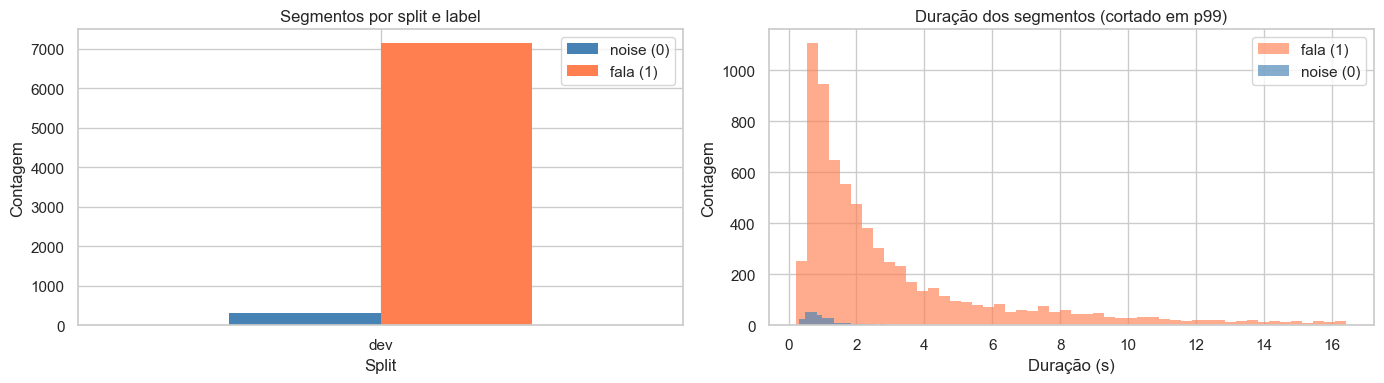

In [3]:
label_counts = df_segments["label"].value_counts().rename({0: "noise/silêncio", 1: "fala/vocal"})
print("Distribuição de labels nos segmentos:")
print(label_counts.to_string())
print(f"\nProporção de fala: {label_counts.get('fala/vocal', 0) / label_counts.sum():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Contagem por split e label
pivot = df_segments.groupby(["split", "label"]).size().unstack(fill_value=0)
pivot.columns = [f"label={c}" for c in pivot.columns]
pivot.plot(kind="bar", ax=axes[0], color=["steelblue", "coral"], edgecolor="none")
axes[0].set_title("Segmentos por split e label")
axes[0].set_xlabel("Split")
axes[0].set_ylabel("Contagem")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(["noise (0)", "fala (1)"])

# Duração por label
for lbl, color, name in [(1, "coral", "fala (1)"), (0, "steelblue", "noise (0)")]:
    data = df_segments[df_segments["label"] == lbl]["duration_sec"]
    clip = np.percentile(data, 99)
    axes[1].hist(data[data <= clip], bins=50, alpha=0.65, color=color, label=name, edgecolor="none")
axes[1].set_title("Duração dos segmentos (cortado em p99)")
axes[1].set_xlabel("Duração (s)")
axes[1].set_ylabel("Contagem")
axes[1].legend()

plt.tight_layout()
plt.savefig("plots/segment_label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Grid Temporal por Sessão — Distribuição de Records (Blocos)

Simulamos o grid de frames como será na extração de features, usando `HOP_SIZE = 20ms`.

Um **record** é uma sequência contígua de frames com o mesmo label.  
É a unidade que o LSTM receberá como entrada — classificando o bloco inteiro como fala (1) ou ruído (0).

Esta análise responde: *qual o comprimento típico de um record em número de frames?*

In [4]:
def build_frame_labels(session_df: pd.DataFrame, hop_size: float = HOP_SIZE) -> np.ndarray:
    """
    Cria array de labels por frame para uma sessão.
    Speakers sobrepostos: OR logic (qualquer um falando → label=1).
    """
    max_time = session_df["end_sec"].max()
    n_frames = int(np.ceil(max_time / hop_size)) + 1
    labels = np.zeros(n_frames, dtype=np.int8)

    speech_segs = session_df[session_df["label"] == 1]
    for _, seg in speech_segs.iterrows():
        f_start = int(np.floor(seg["start_sec"] / hop_size))
        f_end   = int(np.ceil(seg["end_sec"]   / hop_size))
        labels[f_start : f_end + 1] = 1

    return labels


def get_block_lengths(labels: np.ndarray) -> tuple:
    """Retorna (speech_blocks, noise_blocks): listas com comprimentos em frames de cada bloco."""
    if len(labels) == 0:
        return [], []

    speech_blocks, noise_blocks = [], []
    current, count = labels[0], 1

    for lab in labels[1:]:
        if lab == current:
            count += 1
        else:
            (speech_blocks if current == 1 else noise_blocks).append(count)
            current, count = lab, 1
    (speech_blocks if current == 1 else noise_blocks).append(count)

    return speech_blocks, noise_blocks

In [5]:
all_speech_blocks = []
all_noise_blocks  = []

session_stats = []
for session_id, session_df in df_segments.groupby("session_id"):
    frame_labels = build_frame_labels(session_df)
    sb, nb = get_block_lengths(frame_labels)
    all_speech_blocks.extend(sb)
    all_noise_blocks.extend(nb)
    session_stats.append({
        "session_id":     session_id,
        "n_frames":       len(frame_labels),
        "duration_min":   len(frame_labels) * HOP_SIZE / 60,
        "speech_ratio":   frame_labels.sum() / len(frame_labels),
        "n_speech_blocks": len(sb),
        "n_noise_blocks":  len(nb),
    })

df_sessions = pd.DataFrame(session_stats).set_index("session_id")
speech_arr = np.array(all_speech_blocks)
noise_arr  = np.array(all_noise_blocks)

print(f"Total de blocos de fala  : {len(speech_arr):,}")
print(f"Total de blocos de ruído : {len(noise_arr):,}")
print()
print(df_sessions.round(3))

Total de blocos de fala  : 771
Total de blocos de ruído : 771

            n_frames  duration_min  speech_ratio  n_speech_blocks  \
session_id                                                          
S02          1112761       148.368         0.948              391   
S09           894940       119.325         0.767              380   

            n_noise_blocks  
session_id                  
S02                    391  
S09                    380  


### 2.1 Distribuição do comprimento dos blocos

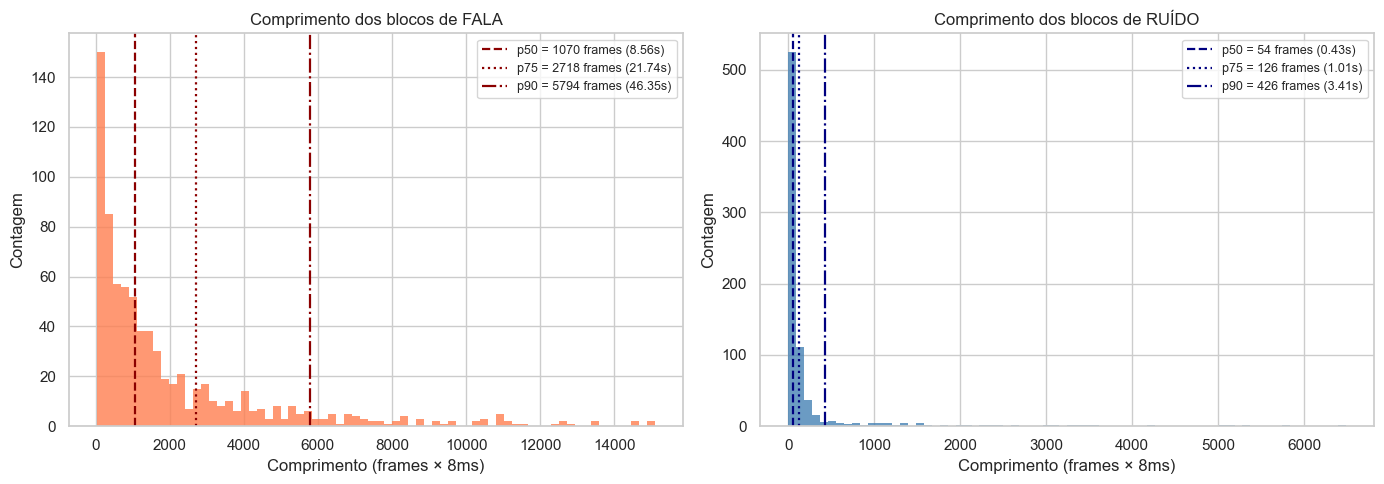

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

PERCENTILES = [(50, "--", "p50"), (75, ":", "p75"), (90, "-.", "p90")]

for ax, arr, color, line_color, title in [
    (axes[0], speech_arr, "coral",     "darkred", "Comprimento dos blocos de FALA"),
    (axes[1], noise_arr,  "steelblue", "navy",    "Comprimento dos blocos de RUÍDO"),
]:
    clip = np.percentile(arr, 99)
    ax.hist(arr[arr <= clip], bins=70, color=color, alpha=0.80, edgecolor="none")
    for pct, ls, label in PERCENTILES:
        val = np.percentile(arr, pct)
        ax.axvline(val, linestyle=ls, color=line_color, linewidth=1.6,
                   label=f"{label} = {val:.0f} frames ({val * HOP_SIZE:.2f}s)")
    ax.set_title(title)
    ax.set_xlabel(f"Comprimento (frames × {int(HOP_SIZE * 1000)}ms)")
    ax.set_ylabel("Contagem")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("plots/record_length_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.2 Estatísticas e recomendação de `seq_len`

seq_len menor → mais records, menos contexto por inferência.
seq_len maior → menos records, mais contexto, mais memória.

In [8]:
print(f"{'=' * 58}")
print(f"  ESTATÍSTICAS — BLOCOS DE FALA (frames @ {int(HOP_SIZE*1000)}ms)")
print(f"{'=' * 58}")
s = pd.Series(speech_arr)
print(s.describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]).round(1).to_string())

print()
print(f"{'=' * 58}")
print(f"  CANDIDATOS A seq_len")
print(f"{'=' * 58}")
for name, pct in [("Mediana (p50)", 50), ("p75", 75), ("p90", 90), ("p95", 95)]:
    frames = int(np.percentile(speech_arr, pct))
    duration = frames * HOP_SIZE
    print(f"  {name:<18}: {frames:>4} frames  (~{duration:.2f}s)")

  ESTATÍSTICAS — BLOCOS DE FALA (frames @ 8ms)
count      771.0
mean      2258.1
std       3294.3
min         42.0
25%        362.0
50%       1070.0
75%       2717.5
90%       5794.0
95%       8785.5
max      25983.0

  CANDIDATOS A seq_len
  Mediana (p50)     : 1070 frames  (~8.56s)
  p75               : 2717 frames  (~21.74s)
  p90               : 5794 frames  (~46.35s)
  p95               : 8785 frames  (~70.28s)
